# Baseline 3: CNN + BiLSTM

This notebook contains the code for training a **ResNet-18 + 2-layer BiLSTM** model on our preprocessed face crops. This is the first temporal baseline in our project. Unlike Xception and EfficientNet (which run frame-by-frame and just average the logits), this model actually models the time dimension by feeding per-frame features through a recurrent network.

The idea is to capture temporal artifacts that frame-level models miss. That is, things like unnatural blinking, inconsistent motion, or flicker between frames, which are common in deepfakes.

**Approach:** ResNet-18 extracts a 512-dim feature vector per frame. A 2-layer BiLSTM processes the 24 features as a sequence. The final BiLSTM hidden state (forward + backward concatenated) is fed to a small classification head for the binary prediction.

**Reference:** Güera & Delp, *"Deepfake Video Detection Using Recurrent Neural Networks"*, AVSS 2018.

### To view TensorBoard
In PowerShell, use the following command:
```powershell
tensorboard --logdir ./results
```
Open http://localhost:6006 in your browser.

## 1. Setup

In [1]:
# Keep track of time
import time

start_time = time.perf_counter()

In [2]:
# Import nercessary libraries and the shared utilities
import json
from pathlib import Path
import random

import numpy as np
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models

# Import shared utilities
from utils import (
    PREPROCESSED_TENSORS_DIR_PATH,
    RESULTS_DIR_PATH,
    DeepfakeClipDataset,
    make_balanced_sampler,
    run_training,
    evaluate,
    load_checkpoint,
    plot_training_curves,
)

In [3]:
# Set the seed value
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# Enable cuDNN auto-tuner to select the fastest convolution algorithms
torch.backends.cudnn.benchmark = True

In [4]:
# Set the device
if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"GPU Name is:{torch.cuda.get_device_name(0)}")
else:
    DEVICE = "cpu"

GPU Name is:NVIDIA GeForce RTX 5080


In [5]:
# Set the hyper-parameter
model_name = "cnn_lstm_baseline"
#number_of_epochs = 2 # For dry-run
number_of_epochs = 25
batch_size = 16 # ResNet-18 is light. 16 clips × 24 frames = 384 frames per batch, still fits.
learning_rate = 1e-4
weight_decay = 1e-4
early_stopping_patience = 5

# LSTM-specific hyper-parameters
lstm_hidden_size = 256
lstm_num_layers = 2
lstm_dropout = 0.3

## 2. Build datasets and dataloaders

We use the balanced sampler on the train split to oversample reals (since fakes outnumber them 4:1).

In [6]:
# Build the dataset
splits_json_path = PREPROCESSED_TENSORS_DIR_PATH / "splits.json"
assert splits_json_path.exists(), f"Missing {splits_json_path}."

train_dataset = DeepfakeClipDataset(splits_json_path, "train", PREPROCESSED_TENSORS_DIR_PATH, training_augment=True)
validation_dataset = DeepfakeClipDataset(splits_json_path, "validation", PREPROCESSED_TENSORS_DIR_PATH, training_augment=False)
test_dataset = DeepfakeClipDataset(splits_json_path, "test", PREPROCESSED_TENSORS_DIR_PATH, training_augment=False)

print(f"Train: {len(train_dataset)} clips")
print(f"validation:   {len(validation_dataset)} clips")
print(f"Test:  {len(test_dataset)} clips")

Train: 2799 clips
validation:   349 clips
Test:  351 clips


In [7]:
# Make the training dataset balanced
train_sampler = make_balanced_sampler(train_dataset)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=train_sampler,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

## 3. Define the model

Two parts:

1. **ResNet-18 feature extractor.** We load the ImageNet-pretrained ResNet-18 from torchvision and replace its final classifier with `nn.Identity()`, so the network outputs the 512-dim global-pooled features directly instead of class scores. This runs on every frame independently.

2. **2-layer BiLSTM + classification head.** The 24 per-frame features are treated as a sequence and fed through a bidirectional LSTM. We take the final hidden state of the last layer (forward and backward concatenated, so 512-dim total) and pass it through a small MLP to get the clip-level binary logit.

Bidirectional matters here. A deepfake artifact at frame 15 might only become obvious in the context of frames before and after it.

In [8]:
class CnnLstmClipModel(nn.Module):
    """ResNet-18 features per frame, then a 2-layer BiLSTM over the 24 frames, then a binary head.
    
    This is the first temporal baseline. Unlike Xception/EfficientNet which just average per-frame logits,
    this model actually learns motion patterns across the clip.
    """
    
    def __init__(self, lstm_hidden_size=256, lstm_num_layers=2, lstm_dropout=0.3, pretrained=True):
        super().__init__()
        # Load ResNet-18 and chop off the final fully connected layer.
        # We keep everything up to global-avg-pool, so output is a 512-dim feature vector per frame.
        resnet_weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
        resnet = models.resnet18(weights=resnet_weights)
        self.feature_dim = resnet.fc.in_features  # 512 for ResNet-18
        # nn.Identity() replaces the classifier so the network outputs the pooled features directly.
        resnet.fc = nn.Identity()
        self.cnn_feature_extractor = resnet
        
        # BiLSTM over the per-frame feature sequence
        self.bilstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=lstm_dropout if lstm_num_layers > 1 else 0.0,
        )
        
        # Binary classification head on top of the final BiLSTM state.
        # BiLSTM doubles the hidden size (forward + backward).
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )
    
    def forward(self, clip):
        # clip: [B, T, 3, H, W]
        batch_size, number_of_frames, channels, height, width = clip.shape
        
        # Flatten time into batch and run the CNN: [B*T, 3, H, W] -> [B*T, 512]
        flat_frames = clip.view(batch_size * number_of_frames, channels, height, width)
        per_frame_features = self.cnn_feature_extractor(flat_frames)
        
        # Reshape back to a sequence: [B, T, 512]
        per_frame_features = per_frame_features.view(batch_size, number_of_frames, self.feature_dim)
        
        # Run the BiLSTM. We take the final hidden state (which has seen the full sequence).
        # lstm_output: [B, T, hidden*2], final_hidden: [num_layers*2, B, hidden]
        lstm_output, (final_hidden, _) = self.bilstm(per_frame_features)
        
        # Concatenate the forward and backward hidden states of the LAST layer.
        # final_hidden layout: [layer0_fwd, layer0_bwd, layer1_fwd, layer1_bwd, ...]
        forward_last = final_hidden[-2]   # [B, hidden]
        backward_last = final_hidden[-1]  # [B, hidden]
        clip_representation = torch.cat([forward_last, backward_last], dim=1)  # [B, hidden*2]
        
        clip_logits = self.classifier(clip_representation)  # [B, 1]
        return clip_logits


model = CnnLstmClipModel(
    lstm_hidden_size=lstm_hidden_size,
    lstm_num_layers=lstm_num_layers,
    lstm_dropout=lstm_dropout,
    pretrained=True,
).to(DEVICE)

num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_parameters:,}  ({num_parameters/1e6:.1f}M)")

Trainable parameters: 14,396,225  (14.4M)


## 4. Optimizer, scheduler, loss

In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# We use Cosine annealing as it gradually decays the LR over the training run
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=number_of_epochs)

loss_function = nn.BCEWithLogitsLoss()

print(f"Optimizer: AdamW, lr={learning_rate}, weight_decay={weight_decay}")
print(f"Scheduler: CosineAnnealingLR over {number_of_epochs} epochs")
print(f"Loss: BCEWithLogitsLoss")

Optimizer: AdamW, lr=0.0001, weight_decay=0.0001
Scheduler: CosineAnnealingLR over 25 epochs
Loss: BCEWithLogitsLoss


## 5. Train

The `run_training` helper from `utils.py` handles the full loop. That is, training epochs, validation, TensorBoard logging, early stopping, and saving the best checkpoint.

In [10]:
best_checkpoint_path = run_training(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    loss_function=loss_function,
    device=DEVICE,
    model_name=model_name,
    number_of_epochs=number_of_epochs,
    early_stopping_patience=early_stopping_patience,
    use_mixed_precision=True,
)


Training: cnn_lstm_baseline
TensorBoard logs: results\cnn_lstm_baseline\tensorboard
  Run `tensorboard --logdir C:\x-ion\TEST\results` to view live curves.



Epoch  1/25  train_loss=0.6051  validation_loss=0.3970  validation_auc=0.8919  validation_acc=0.8338  (66.9s)


Epoch  2/25  train_loss=0.3683  validation_loss=0.4977  validation_auc=0.9171  validation_acc=0.7908  (50.1s) *


Epoch  3/25  train_loss=0.2382  validation_loss=0.3762  validation_auc=0.9713  validation_acc=0.8510  (48.3s) *


Epoch  4/25  train_loss=0.1698  validation_loss=0.2288  validation_auc=0.9666  validation_acc=0.9255  (48.1s)


...

Epoch 16/25  train_loss=0.0260  validation_loss=0.2309  validation_auc=0.9807  validation_acc=0.9513  (45.2s)


Epoch 17/25  train_loss=0.0132  validation_loss=0.2277  validation_auc=0.9817  validation_acc=0.9513  (45.0s)


Epoch 18/25  train_loss=0.0222  validation_loss=0.2323  validation_auc=0.9822  validation_acc=0.9542  (45.1s)


Epoch 19/25  train_loss=0.0128  validation_loss=0.2550  validation_auc=0.9815  validation_acc=0.9456  (45.1s)


Epoch 20/25  train_loss=0.0091  validation_loss=0.2319  validation_auc=0.9811  validation_acc=0.9513  (45.6s)

Early stopping at epoch 20 (no improvement for 5 epochs).

Training done. Best vvalidation AUC: 0.9826
Best checkpoint: results\cnn_lstm_baseline\best_model.pt


## 6. Plot training curves

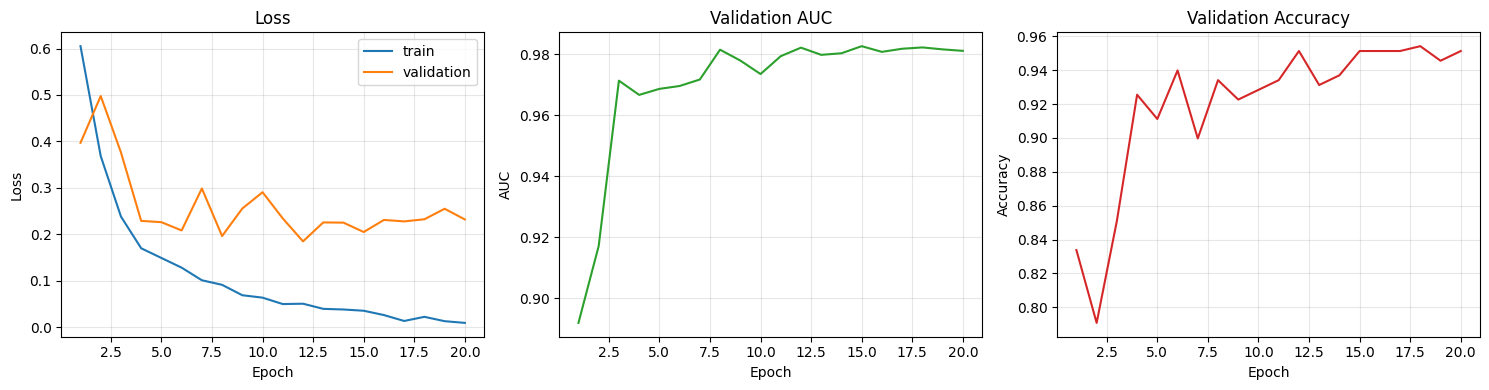

In [11]:
history_path = RESULTS_DIR_PATH / model_name / "training_history.json"
curves_save_path = RESULTS_DIR_PATH / model_name / "training_curves.png"
plot_training_curves(history_path, save_path=curves_save_path)

## 7. Test-set evaluation

Load the best checkpoint and evaluate on the held-out test split. This is the number we'll report in the report.

In [12]:
load_checkpoint(model, best_checkpoint_path, DEVICE)
test_loss, test_metrics, test_predictions = evaluate(model, test_loader, loss_function, DEVICE)

print("\n=== Test set results ===")
print(f"Loss:      {test_loss:.4f}")
print(f"AUC:       {test_metrics['auc']:.4f}")
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1:        {test_metrics['f1']:.4f}")
print(f"Confusion matrix [[TN, FP], [FN, TP]]: {test_metrics['confusion_matrix']}")

# Save for later aggregation across all models
test_metrics_save_path = RESULTS_DIR_PATH / model_name / "final_test_metrics.json"
with open(test_metrics_save_path, "w") as f:
    json.dump({"test_loss": test_loss, "test_metrics": test_metrics}, f, indent=2)

# Also save per-sample predictions for the per-class breakdown later
predictions_save_path = RESULTS_DIR_PATH / model_name / "test_predictions.json"
with open(predictions_save_path, "w") as f:
    json.dump(test_predictions, f, indent=2)

print(f"\nSaved test metrics to {test_metrics_save_path}")


=== Test set results ===
Loss:      0.1331
AUC:       0.9805
Accuracy:  0.9744
Precision: 0.9823
Recall:    0.9858
F1:        0.9840
Confusion matrix [[TN, FP], [FN, TP]]: [[65, 5], [4, 277]]

Saved test metrics to results\cnn_lstm_baseline\final_test_metrics.json


## 8. Per-manipulation breakdown

Split test-set predictions by manipulation method. This will tells us which fake types the CNN+LSTM handles best. We expect this temporal model to do better than the frame-level baselines on manipulations that produce flicker or motion artifacts (e.g. FaceSwap).

In [13]:
# Group predictions by class name
predictions_by_class = defaultdict(list)
labels_by_class = defaultdict(list)
for probability, true_label, class_name in zip(
    test_predictions["predicted_probs"],
    test_predictions["true_labels"],
    test_predictions["class_names"],
):
    predictions_by_class[class_name].append(probability)
    labels_by_class[class_name].append(true_label)

print("\n=== Per-class accuracy on test set (threshold = 0.5) ===")
print(f"{'Class':<20} {'N':>4}  {'Accuracy':>10}  {'Mean prob':>10}")
print("-" * 50)
for cls_name in sorted(predictions_by_class.keys()):
    probs = np.array(predictions_by_class[cls_name])
    true_labels = np.array(labels_by_class[cls_name])
    predicted = (probs >= 0.5).astype(int)
    accuracy = (predicted == true_labels).mean()
    print(f"{cls_name:<20} {len(probs):>4}  {accuracy:>10.4f}  {probs.mean():>10.4f}")


=== Per-class accuracy on test set (threshold = 0.5) ===
Class                   N    Accuracy   Mean prob
--------------------------------------------------
Deepfakes              71      1.0000      0.9968
Face2Face              70      1.0000      0.9976
FaceSwap               70      0.9714      0.9675
NeuralTextures         70      0.9714      0.9570
original               70      0.9286      0.0770


In [14]:
end_time = time.perf_counter()
time_elapsed = end_time - start_time
hours_elapsed = int(time_elapsed // 3600)
minutes_elapsed = int((time_elapsed % 3600) // 60)

print(f"Total execution time for {model_name}: {hours_elapsed:,}h {minutes_elapsed}m")

Total execution time for cnn_lstm_baseline: 0h 16m
